# Premier League 2025-26: Predicted vs Actual Goals + Assists

**Aim:** predict each outfield player's goals + assists (`goalsAssistsSum`) from their shooting and chance-creation stats, compare with what actually happened, and choose the best model.

**Day 1 (sections 1–10):** load and clean the data, remove leakage columns, look at the data, compute the xG + xA benchmark, and fit a first Ridge model.

**Day 2 (sections 11–14):** compare Linear Regression, Ridge, Random Forest and Gradient Boosting on cross-validation, choose the best model, and plot predicted vs actual for every player.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
DATA_PATH = Path("../data/premier_league_complete_stats_whole2025-2026_season.csv")
OUTPUT_DIR = Path("../outputs")

## 2. Load the data

Check the real column names first so no feature name is made up.

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df["team_name"].value_counts())

(78, 113)
team_name
Manchester United    27
Manchester City      26
Arsenal              25
Name: count, dtype: int64


In [3]:
list(df.columns)

['player_name',
 'player_id',
 'team_name',
 'team_id',
 'position',
 'accurateChippedPasses',
 'accurateCrosses',
 'accurateCrossesPercentage',
 'accurateFinalThirdPasses',
 'accurateLongBalls',
 'accurateLongBallsPercentage',
 'accurateOppositionHalfPasses',
 'accurateOwnHalfPasses',
 'accuratePasses',
 'accuratePassesPercentage',
 'aerialDuelsWon',
 'aerialDuelsWonPercentage',
 'aerialLost',
 'appearances',
 'assists',
 'attemptPenaltyMiss',
 'attemptPenaltyPost',
 'ballRecovery',
 'bigChancesCreated',
 'bigChancesMissed',
 'blockedShots',
 'cleanSheet',
 'clearances',
 'countRating',
 'directRedCards',
 'dispossessed',
 'dribbledPast',
 'duelLost',
 'errorLeadToGoal',
 'errorLeadToShot',
 'expectedAssists',
 'expectedGoals',
 'fouls',
 'freeKickGoal',
 'goalConversionPercentage',
 'goalKicks',
 'goals',
 'goalsAssistsSum',
 'goalsConceded',
 'goalsConcededInsideTheBox',
 'goalsConcededOutsideTheBox',
 'goalsFromInsideTheBox',
 'goalsFromOutsideTheBox',
 'goalsPrevented',
 'groundDu

## 3. Cleaning

Three filters, in order:
1. **Drop rows with no stats.** 16 squad players have no stats at all (they never played), so there is nothing to learn from.
2. **Outfield only.** Goalkeepers almost never score or assist, and their stats measure a different job.
3. **At least 5 appearances.** A player with 1–2 games has G+A that's mostly noise.

In [4]:
print("Rows with no appearances recorded:", df["appearances"].isna().sum())

players = df[df["appearances"].notna()]
players = players[~players["position"].str.startswith("G")]
players = players[players["appearances"] >= 5].copy()

print("Players after cleaning:", len(players))
print(players["position"].value_counts())

Rows with no appearances recorded: 16
Players after cleaning: 55
position
D    23
M    22
F    10
Name: count, dtype: int64


## 4. Leakage check

A column **leaks** if it contains the answer, or is calculated from it. For example, `goals` is part of `goalsAssistsSum`, so a model given `goals` would look amazing and learn nothing useful.

The list below is the one from the project instructions, plus extras found in this CSV:
- **Penalty and foot-specific goals:** `penaltyGoals`, `penaltyConversion`, `leftFootGoals`, `rightFootGoals`.
- **Rates with goals in them:** `scoringFrequency` (minutes per goal), `setPieceConversion`.
- **Ratings:** `rating`, `totalRating`, `countRating`, `totwAppearances`. Rating systems reward goals and assists, so they indirectly contain the target.
- **`passToAssist`:** not identical to assists here (it matches in only 29% of rows), but it's unclear how it's defined, so it's safer left out.

In [5]:
TARGET = "goalsAssistsSum"

LEAKAGE_COLS = [
    "goals", "assists", "goalsAssistsSum", "goalConversionPercentage",
    "goalsFromInsideTheBox", "goalsFromOutsideTheBox", "headedGoals", "freeKickGoal",
    "penaltyGoals", "penaltyConversion", "leftFootGoals", "rightFootGoals",
    "scoringFrequency", "setPieceConversion", "passToAssist",
    "rating", "totalRating", "countRating", "totwAppearances",
]

# Provider's own estimate: used as the benchmark, never as a feature
BENCHMARK_COLS = ["expectedGoals", "expectedAssists"]

## 5. Features

These come from the candidate list in the instructions, checked against the real column names above.

`totalAttemptAssist` is also in the CSV, but it's identical to `keyPasses` (correlation 1.00), so only `keyPasses` is used. Giving the model the same column twice adds nothing and makes Ridge's coefficients harder to read.

In [6]:
print(players[["keyPasses", "totalAttemptAssist"]].corr().round(3))

                    keyPasses  totalAttemptAssist
keyPasses                 1.0                 1.0
totalAttemptAssist        1.0                 1.0


In [7]:
NUMERIC_FEATURES = [
    # Shooting and chance creation
    "totalShots", "shotsOnTarget", "blockedShots",
    "bigChancesCreated", "bigChancesMissed", "keyPasses",
    "attemptPenaltyMiss", "attemptPenaltyPost",
    # Involvement
    "appearances", "minutesPlayed",
    "accurateFinalThirdPasses", "accurateOppositionHalfPasses",
    "accurateCrosses", "dispossessed",
]
CATEGORICAL_FEATURES = ["position"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

leaked = set(FEATURES) & set(LEAKAGE_COLS + BENCHMARK_COLS)
assert not leaked, f"Leakage columns in features: {leaked}"
print("No leakage columns in the feature list.")

No leakage columns in the feature list.


**Missing values:** after cleaning, check what's still missing. A missing count means the event never happened, so it's filled with 0.

In [8]:
print("Missing in features:", players[NUMERIC_FEATURES].isna().sum().sum())
print("Missing in benchmark:")
print(players.loc[players[BENCHMARK_COLS].isna().any(axis=1), ["player_name", *BENCHMARK_COLS]])

players[NUMERIC_FEATURES] = players[NUMERIC_FEATURES].fillna(0)
players[BENCHMARK_COLS] = players[BENCHMARK_COLS].fillna(0)

Missing in features: 0
Missing in benchmark:
    player_name  expectedGoals  expectedAssists
49  John Stones            NaN         0.087636


## 6. Exploring the data

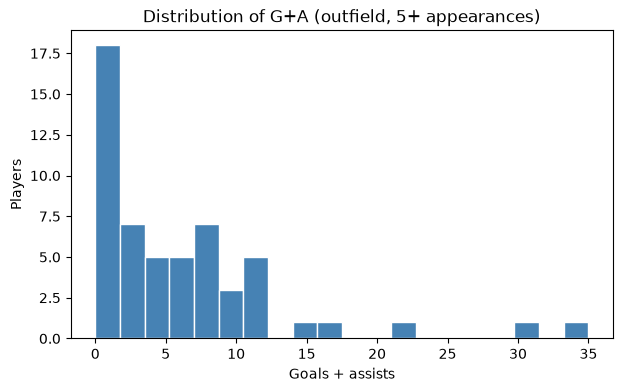

count    55.000000
mean      6.109091
std       7.051852
min       0.000000
25%       1.000000
50%       5.000000
75%       8.000000
max      35.000000
Name: goalsAssistsSum, dtype: float64

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(players[TARGET], bins=20, color="steelblue", edgecolor="white")
ax.set_xlabel("Goals + assists")
ax.set_ylabel("Players")
ax.set_title("Distribution of G+A (outfield, 5+ appearances)")
plt.show()

players[TARGET].describe()

The target is **right-skewed**: most players have a handful of G+A and a few attackers have far more. The high-G+A players will dominate squared-error losses, which is one reason MAE is also reported.

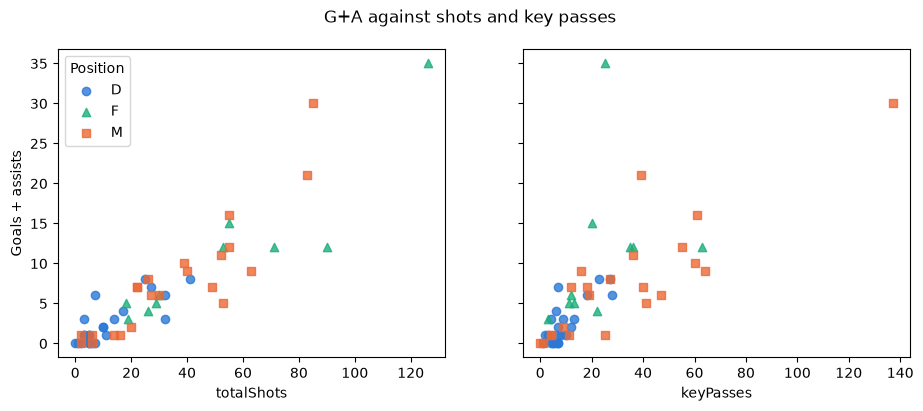

In [10]:
POSITION_COLORS = {"D": "#2a78d6", "M": "#eb6834", "F": "#1baf7a"}
POSITION_MARKERS = {"D": "o", "M": "s", "F": "^"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col in zip(axes, ["totalShots", "keyPasses"]):
    for pos, grp in players.groupby("position"):
        ax.scatter(grp[col], grp[TARGET], label=pos, color=POSITION_COLORS[pos],
                   marker=POSITION_MARKERS[pos], alpha=0.8)
    ax.set_xlabel(col)
axes[0].set_ylabel("Goals + assists")
axes[0].legend(title="Position")
fig.suptitle("G+A against shots and key passes")
plt.show()

In [11]:
players.groupby("position")[TARGET].agg(["count", "mean", "median", "max"]).round(1)

,count,mean,median,max
position,,,,
D,23,2.5,1.0,8.0
F,10,10.9,9.0,35.0
M,22,7.7,7.0,30.0


## 7. Train/test split

80/20 split with `random_state=42`. The same split is used for the benchmark and the models so they're compared on the same players.

With 55 players, the test set is only 11 players, so one unlucky split can move the scores a lot. Compare the two sets:

In [12]:
X = players[FEATURES]
y = players[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} players, test: {len(X_test)} players")
pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()}).round(2)

Train: 44 players, test: 11 players


,train,test
count,44.00,11.00
mean,6.80,3.36
std,7.67,2.25
min,0.00,1.00
25%,1.00,1.00
50%,6.00,4.00
75%,9.25,5.00
max,35.00,7.00


The test set has a much smaller spread of G+A (std ≈ 2.3 vs ≈ 7.7) and none of the high scorers. R² measures how much of the target's *variance* a model explains, and there's very little variance in this test set, so **test R² will look bad for any model**. MAE (average error in G+A) is more trustworthy here, and section 10 adds cross-validation for a fairer picture.

## 8. Benchmark: xG + xA

`expectedGoals + expectedAssists` is the data provider's estimate of how many G+A a player *should* have. It's built from shot-level data (shot location, angle, type of pass) that isn't in this CSV, so it's a strong target to match.

In [13]:
players["xg_xa"] = players["expectedGoals"] + players["expectedAssists"]

def scores(y_true, y_pred):
    return {"R2": r2_score(y_true, y_pred), "MAE": mean_absolute_error(y_true, y_pred)}

bench_all = scores(y, players["xg_xa"])
bench_test = scores(y_test, players.loc[X_test.index, "xg_xa"])
pd.DataFrame({"all 55 players": bench_all, "test set (11)": bench_test}).round(3)

,all 55 players,test set (11)
R2,0.894,0.201
MAE,1.580,1.253


On all 55 players xG + xA explains most of the variance (R² ≈ 0.89). On the small test set its R² drops sharply, but its MAE stays around 1.3 G+A. That confirms the test-set R² problem above is about the split, not the predictor.

## 9. First model: Ridge regression

Why this setup:
- **`Pipeline` + `ColumnTransformer`:** the scaler and encoder are fitted inside the pipeline on training data only, so test-set statistics can't leak into training.
- **`StandardScaler`:** Ridge penalises large coefficients, so features need to be on the same scale for the penalty to be fair.
- **`OneHotEncoder(handle_unknown="ignore")`:** turns `position` into 0/1 columns and won't crash if a split is missing a position.
- **Ridge rather than plain linear regression:** shots, shots on target and big chances missed are strongly correlated. Ridge's penalty keeps the coefficients stable when features overlap like that.
- **Clip at 0:** negative goals + assists is impossible.

In [14]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

ridge = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0)),
])

ridge.fit(X_train, y_train)
ridge_pred = np.clip(ridge.predict(X_test), 0, None)

pd.DataFrame({
    "xG + xA (benchmark)": bench_test,
    "Ridge": scores(y_test, ridge_pred),
}).T.round(3)

,R2,MAE
xG + xA (benchmark),0.201,1.253
Ridge,-0.885,2.081


In [15]:
test_view = pd.DataFrame({
    "player": players.loc[X_test.index, "player_name"],
    "position": X_test["position"],
    "actual": y_test,
    "ridge": ridge_pred.round(1),
    "xG + xA": players.loc[X_test.index, "xg_xa"].round(1),
}).sort_values("actual", ascending=False)
test_view

,player,position,actual,ridge,xG + xA
6,Martin Ødegaard,M,7.0,6.0,4.9
28,Marc Guéhi,D,6.0,8.7,6.4
21,Gabriel Martinelli,F,5.0,8.0,5.3
59,Amad Diallo,M,5.0,12.8,10.4
36,Joško Gvardiol,D,4.0,2.7,3.1
14,Noni Madueke,F,4.0,5.8,4.1
46,Savinho,M,2.0,5.3,3.9
37,Nico González,M,1.0,1.6,1.8
15,Ben White,D,1.0,1.3,1.1
56,Matthijs de Ligt,D,1.0,1.7,2.2


## 10. Stability check: 5-fold cross-validation

To see whether the test-set result is down to the model or the split, the same pipeline is trained and scored 5 times. Each time a different fifth of the players is held out, and every player is tested exactly once. `shuffle=True` because the CSV is sorted by team.

In [16]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(ridge, X, y, cv=cv, scoring=["r2", "neg_mean_absolute_error"])

cv_table = pd.DataFrame({
    "R2": cv_results["test_r2"],
    "MAE": -cv_results["test_neg_mean_absolute_error"],
}, index=[f"fold {i + 1}" for i in range(5)])
cv_table.loc["mean"] = cv_table.mean()
cv_table.loc["std"] = cv_table.iloc[:5].std()
cv_table.round(3)

,R2,MAE
fold 1,-0.885,2.081
fold 2,0.805,2.444
fold 3,0.881,1.953
fold 4,0.788,2.044
fold 5,0.926,1.104
mean,0.503,1.925
std,0.778,0.496


### Day 1 takeaways

- One fold (the one with the low-spread test players) gives a negative R²; the others give roughly 0.8–0.9. **One 80/20 split isn't enough to judge a model on 55 players.** Day 2 compares models on cross-validated MAE, as set out in `PLAN.md`.
- Ridge's MAE is about 2 G+A per player, worse than the xG + xA benchmark on the test set. That's expected: xG + xA uses shot-quality data we don't have.
- **Day 2:** add Random Forest and Gradient Boosting, compare all models on 5-fold CV MAE, choose the best, and plot predicted vs actual for all 55 players.

*Note: `cross_validate` doesn't clip predictions at 0, so the CV scores above are for unclipped predictions. Day 2 clips the out-of-fold predictions before scoring them.*

# Day 2: choosing the best model

## 11. Four candidate models

All four use the same `preprocess` step from section 9, so the only thing that changes is the model.

- **Linear Regression:** plain least squares with no penalty. It's here to test the Day 1 argument for Ridge (section 9): if the correlated shooting features really are a problem, it should show up in its coefficients.
- **Ridge:** linear. It assumes each extra shot or key pass adds a fixed amount of G+A. Simple and hard to overfit.
- **Random Forest:** averages many decision trees, each trained on a random sample of players. It can pick up non-linear patterns (e.g. shots matter more for forwards) and interactions.
- **Gradient Boosting:** builds trees one after another, each correcting the errors of the previous ones. Often the most accurate on tabular data, but also the easiest to overfit.

**Why the tree settings are small:** with 55 players, a deep tree can end up with one player per leaf and just memorise them. `max_depth`, `min_samples_leaf` and a low `learning_rate` keep the trees simple. The trees don't need scaled features, but scaling doesn't hurt them, and one shared pipeline keeps the comparison fair.

In [17]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict

MODELS = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=4, min_samples_leaf=3, random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, max_depth=2, learning_rate=0.05, subsample=0.8,
        random_state=RANDOM_STATE,
    ),
}

def make_pipeline(model):
    return Pipeline([("preprocess", preprocess), ("model", model)])

## 12. Comparing the models

**How the comparison works** (the rule from `PLAN.md`):
1. `cross_val_predict` with the same 5 folds as section 10 gives an **out-of-fold** prediction for every player: a prediction from a model that never saw that player during training.
2. Predictions are clipped at 0.
3. MAE and R² are scored separately on each fold, then averaged. The spread (std) across folds shows how much the score depends on which players end up in the test fold.
4. The xG + xA benchmark is scored on the same folds, so every row of the table is judged on the same players.

**The main metric is CV MAE:** the average error in G+A per player, which is easy to explain and much more stable than R² on 11-player folds.

In [18]:
fold_ids = np.empty(len(X), dtype=int)
for fold, (_, test_idx) in enumerate(cv.split(X)):
    fold_ids[test_idx] = fold

def fold_scores(pred):
    """Score predictions fold by fold, the same way for every model."""
    mae = [mean_absolute_error(y[fold_ids == f], pred[fold_ids == f]) for f in range(5)]
    r2 = [r2_score(y[fold_ids == f], pred[fold_ids == f]) for f in range(5)]
    return {
        "CV MAE": np.mean(mae), "CV MAE std": np.std(mae, ddof=1),
        "CV R2": np.mean(r2), "CV R2 std": np.std(r2, ddof=1),
    }

oof_preds = {"xG + xA (benchmark)": players["xg_xa"].to_numpy()}
for name, model in MODELS.items():
    pred = cross_val_predict(make_pipeline(model), X, y, cv=cv)
    oof_preds[name] = np.clip(pred, 0, None)

results = pd.DataFrame({name: fold_scores(pred) for name, pred in oof_preds.items()}).T

The table also keeps the 80/20 test-set scores from Day 1, so it matches the project instructions. Remember those are based on just 11 low-spread players.

In [19]:
test_scores = {"xG + xA (benchmark)": bench_test}
for name, model in MODELS.items():
    fitted = make_pipeline(model).fit(X_train, y_train)
    test_scores[name] = scores(y_test, np.clip(fitted.predict(X_test), 0, None))

results["test MAE"] = [test_scores[n]["MAE"] for n in results.index]
results["test R2"] = [test_scores[n]["R2"] for n in results.index]
results.round(3)

,CV MAE,CV MAE std,CV R2,CV R2 std,test MAE,test R2
xG + xA (benchmark),1.580,0.494,0.747,0.310,1.253,0.201
Linear Regression,1.882,0.572,0.512,0.775,2.018,-0.871
Ridge,1.889,0.550,0.504,0.779,2.081,-0.885
Random Forest,2.287,0.768,0.398,0.714,2.131,-0.915
Gradient Boosting,2.512,0.922,0.429,0.529,2.270,-0.921


### Choosing the model

The rule from `PLAN.md`: lowest CV MAE wins; if two models are within one fold-std of each other, choose the simpler one.

In [20]:
model_results = results.drop(index="xG + xA (benchmark)").sort_values("CV MAE")
lowest = model_results.index[0]
lowest_std = model_results.loc[lowest, "CV MAE std"]

# Tie-break from PLAN.md: every model within one fold-std of the lowest CV MAE counts as tied
gap = model_results["CV MAE"] - model_results.loc[lowest, "CV MAE"]
tied = gap[gap <= lowest_std].index.tolist()

print(f"Lowest CV MAE: {lowest} ({model_results.loc[lowest, 'CV MAE']:.3f} G+A per player)")
print(f"One fold-std of {lowest}: {lowest_std:.2f}")
for name in model_results.index[1:]:
    print(f"  {name}: +{gap[name]:.3f}{'  (tied)' if name in tied else ''}")

# Among the tied linear models, Ridge is chosen for its stable coefficients (see below)
best_name = "Ridge"
assert best_name in tied

Lowest CV MAE: Linear Regression (1.882 G+A per player)
One fold-std of Linear Regression: 0.57
  Ridge: +0.007  (tied)
  Random Forest: +0.405  (tied)
  Gradient Boosting: +0.630


Linear Regression and Ridge are effectively tied on error, so the choice comes down to which model can be trusted and explained. Both are fitted on all 55 players below to compare their coefficients (per one standard deviation of each feature):

In [21]:
linear_models = {name: make_pipeline(MODELS[name]).fit(X, y) for name in ["Linear Regression", "Ridge"]}
feature_names = linear_models["Ridge"].named_steps["preprocess"].get_feature_names_out()
coefs = pd.DataFrame(
    {name: pipe.named_steps["model"].coef_ for name, pipe in linear_models.items()},
    index=[n.split("__")[1] for n in feature_names],
)
coefs.loc[["totalShots", "shotsOnTarget", "blockedShots", "bigChancesCreated", "bigChancesMissed"]].round(2)

,Linear Regression,Ridge
totalShots,6.13,2.33
shotsOnTarget,-0.50,1.35
blockedShots,-2.62,-0.80
bigChancesCreated,3.75,3.16
bigChancesMissed,1.25,1.73


**Chosen model: Ridge.**

- **Linear Regression and Ridge are tied:** Linear Regression has the lowest CV MAE by only about 0.01 G+A per player, far inside one fold-std (≈ 0.55), and each wins some folds and loses others. Under the tie-break they count as equally accurate.
- **Why Ridge over Linear Regression:** without a penalty, the correlated shooting stats pull against each other. Linear Regression gives `totalShots` a large positive weight and then offsets it with a *negative* weight on `shotsOnTarget` and a big negative one on `blockedShots`, which would mean more shots on target lead to fewer G+A. Its predictions come out about the same, but the coefficients can't be read and would shift with slightly different data. Ridge's coefficients all point the way you'd expect. This is the multicollinearity problem from section 9, now shown with real numbers.
- **Why not the trees:** Gradient Boosting (≈ 2.5) is outside the tie. Random Forest (≈ 2.3) is technically inside it, because the fold-std is large on 55 players, but it's the more complex model, so the tie-break still favours the linear models. Both tree models also have a larger fold-to-fold spread. With 55 players there isn't enough data for trees to learn reliable non-linear patterns, so they mostly add variance. G+A also grows roughly in line with shots and chances created, which is exactly what a linear model assumes. Trees can't predict beyond the range they were trained on either, which hurts on the few extreme players (e.g. a 35-G+A forward).
- **Against the benchmark:** Ridge doesn't beat xG + xA (≈ 1.6). That's expected: xG + xA is built from shot-level data (location, angle, shot type) that isn't in this CSV. Ridge getting within about 0.3 G+A per player of it using only season totals is a reasonable result.

*Not tuned on purpose:* hyperparameter tuning is a planned extra. A quick look at Ridge's `alpha` between 0.1 and 30 moved CV MAE by less than one fold-std, so the default `alpha=1.0` is kept.

## 13. Predicted vs actual

This plot uses the **out-of-fold** predictions from section 12, so all 55 players appear, and none of them was predicted by a model that trained on them. Points on the dashed line were predicted exactly:
- **Above the line:** more G+A than the model expected.
- **Below the line:** fewer G+A than the model expected.

The right-hand panel shows the benchmark the same way, for comparison.

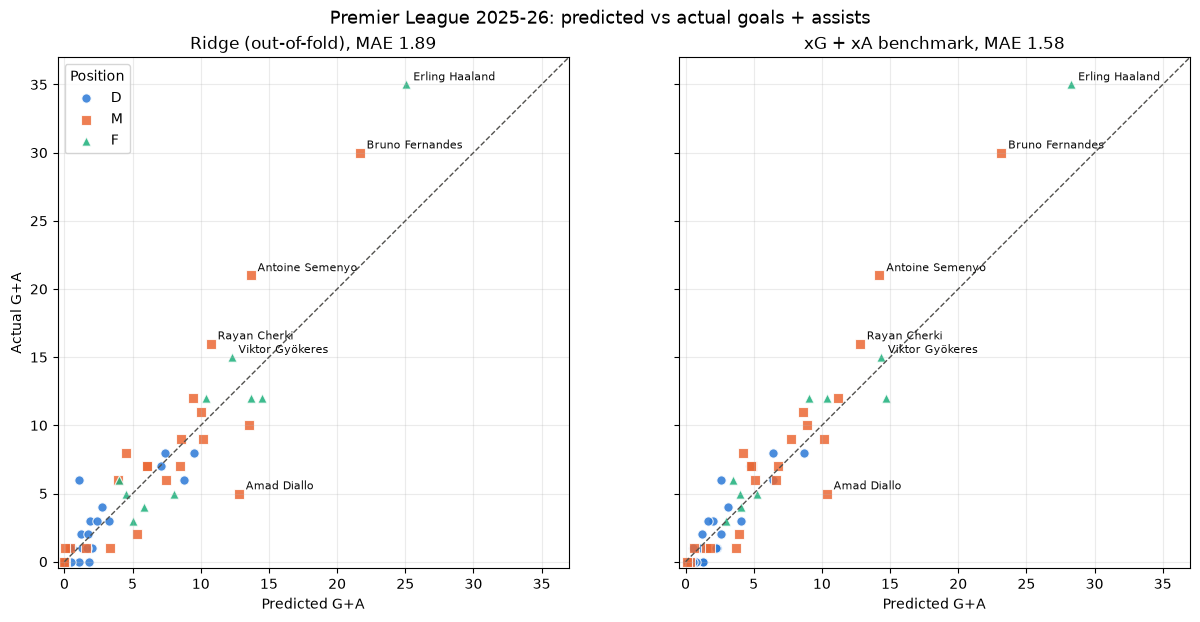

In [22]:
players["predicted"] = oof_preds[best_name]

def plot_pred_vs_actual(ax, pred_col, title):
    for pos in ["D", "M", "F"]:
        grp = players[players["position"] == pos]
        ax.scatter(grp[pred_col], grp[TARGET], label=pos, color=POSITION_COLORS[pos],
                   marker=POSITION_MARKERS[pos], s=45, alpha=0.85,
                   edgecolor="white", linewidth=0.8)
    lim = max(players[TARGET].max(), players[pred_col].max()) + 2
    ax.plot([0, lim], [0, lim], linestyle="--", color="#52514e", linewidth=1)
    ax.set_xlim(-0.5, lim)
    ax.set_ylim(-0.5, lim)
    ax.set_aspect("equal")
    ax.set_xlabel("Predicted G+A")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    # Label only the top 5 and the model's biggest under-prediction, so labels don't pile up
    to_label = pd.concat([
        players.nlargest(5, TARGET),
        players.loc[[(players[TARGET] - players["predicted"]).idxmin()]],
    ])
    for _, row in to_label.iterrows():
        ax.annotate(row["player_name"], (row[pred_col], row[TARGET]),
                    xytext=(5, 3), textcoords="offset points", fontsize=8, color="#0b0b0b")

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2), sharey=True)
best_mae = results.loc[best_name, "CV MAE"]
bench_mae = results.loc["xG + xA (benchmark)", "CV MAE"]
plot_pred_vs_actual(axes[0], "predicted", f"{best_name} (out-of-fold), MAE {best_mae:.2f}")
plot_pred_vs_actual(axes[1], "xg_xa", f"xG + xA benchmark, MAE {bench_mae:.2f}")
axes[0].set_ylabel("Actual G+A")
axes[0].legend(title="Position", loc="upper left")
fig.suptitle("Premier League 2025-26: predicted vs actual goals + assists", fontsize=13)
fig.tight_layout()

OUTPUT_DIR.mkdir(exist_ok=True)
fig.savefig(OUTPUT_DIR / "predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Actual vs predicted, player by player

Sorted by actual G+A. `difference = actual − predicted`: positive means the player produced more than the model expected. `penalties taken` is shown because penalties are an easy source of goals that the features don't fully capture.

In [23]:
player_table = (
    players[["player_name", "team_name", "position", TARGET, "predicted", "xg_xa", "penaltiesTaken"]]
    .rename(columns={"player_name": "player", "team_name": "team", TARGET: "actual",
                     "xg_xa": "xG + xA", "penaltiesTaken": "penalties taken"})
    .assign(difference=lambda t: t["actual"] - t["predicted"])
    .sort_values("actual", ascending=False)
    .reset_index(drop=True)
    .round(1)
)
player_table

,player,team,position,actual,predicted,xG + xA,penalties taken,difference
0,Erling Haaland,Manchester City,F,35.0,25.1,28.3,4.0,9.9
1,Bruno Fernandes,Manchester United,M,30.0,21.7,23.2,6.0,8.3
2,Antoine Semenyo,Manchester City,M,21.0,13.7,14.2,2.0,7.3
3,Rayan Cherki,Manchester City,M,16.0,10.7,12.8,0.0,5.3
4,Viktor Gyökeres,Arsenal,F,15.0,12.3,14.3,3.0,2.7
5,Leandro Trossard,Arsenal,F,12.0,10.4,9.0,0.0,1.6
6,Bukayo Saka,Arsenal,F,12.0,14.5,14.7,1.0,-2.5
7,Phil Foden,Manchester City,M,12.0,9.4,11.2,0.0,2.6
8,Matheus Cunha,Manchester United,F,12.0,13.7,10.3,0.0,-1.7
9,Casemiro,Manchester United,M,11.0,10.0,8.6,0.0,1.0


In [24]:
print("Biggest over-performers (actual above predicted):")
display(player_table.nlargest(5, "difference")[["player", "position", "actual", "predicted", "difference", "penalties taken"]])
print("Biggest under-performers (actual below predicted):")
display(player_table.nsmallest(5, "difference")[["player", "position", "actual", "predicted", "difference", "penalties taken"]])

Biggest over-performers (actual above predicted):


,player,position,actual,predicted,difference,penalties taken
0,Erling Haaland,F,35.0,25.1,9.9,4.0
1,Bruno Fernandes,M,30.0,21.7,8.3,6.0
2,Antoine Semenyo,M,21.0,13.7,7.3,2.0
3,Rayan Cherki,M,16.0,10.7,5.3,0.0
22,Matheus Nunes,D,6.0,1.1,4.9,0.0


Biggest under-performers (actual below predicted):


,player,position,actual,predicted,difference,penalties taken
27,Amad Diallo,M,5.0,12.8,-7.8,0.0
10,Jérémy Doku,M,10.0,13.6,-3.6,0.0
35,Savinho,M,2.0,5.3,-3.3,0.0
26,Gabriel Martinelli,F,5.0,8.0,-3.0,0.0
23,Marc Guéhi,D,6.0,8.7,-2.7,0.0


## 15. Conclusions

- **Best model: Ridge,** chosen on 5-fold CV MAE. Plain Linear Regression was equally accurate, but its coefficients were unstable because the shooting features overlap, so Ridge was kept. It predicts a player's season G+A to within about 1.9 on average, from season totals only.
- **Benchmark still ahead:** the provider's xG + xA is better (MAE ≈ 1.6) because it uses shot-quality data this CSV doesn't have. Matching it wasn't realistic, but Ridge gets close.
- **Tree models lost** on this dataset. 55 players isn't enough for them to beat a linear model, which is a result worth reporting in itself.
- **Big misses:** the four biggest over-performers (Haaland, Bruno Fernandes, Semenyo, Cherki) are also the four highest scorers. Part of that is real (Haaland and Bruno take penalties, and elite finishers score from chances that season totals don't capture). Part of it is the model: Ridge's penalty pulls extreme predictions toward the average, so it under-predicts the very top players. xG + xA also under-predicts them, but by less.
- **Biggest under-performer:** Amad Diallo (5 actual vs ≈ 13 predicted); the benchmark also expected about 10. He took 53 shots and missed 6 big chances for just 2 goals (xG 5.6), and his 41 key passes produced 3 assists (xA 4.8): wasteful, unlucky, or both.

**Limitations**
- Only 55 players from 3 teams, so results may not carry over to the whole league.
- One season of data.
- The single 80/20 test set is too small to judge on, which is why CV is the main evaluation.
- Assists depend on teammates finishing chances, so they're noisier than goals.

**Possible next steps:** the luck-gap analysis, more teams or seasons, tuning, SHAP feature importance.